In [1]:
import os
import pandas as pd
from sqlalchemy import create_engine, text
import numpy as np
from collections import OrderedDict
from RandomForest_PickPack import RandomForestDailyRegressor
from Regresion_Retail import TabularRegressor
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Set these env vars or hardcode them
PGHOST = os.getenv("PGHOST", "localhost")
PGPORT = os.getenv("PGPORT", "5432")
PGDB   = os.getenv("PGDATABASE", "postgres")
PGUSER = os.getenv("PGUSER", "postgres")
PGPASS = os.getenv("PGPASSWORD", "Cantunez-02")


In [3]:
engine = create_engine(f"postgresql+psycopg2://{PGUSER}:{PGPASS}@{PGHOST}:{PGPORT}/{PGDB}")

In [4]:
def load_table(schema: str, table: str) -> pd.DataFrame:
    q = text(f'SELECT * FROM {schema}.{table}')
    with engine.begin() as conn:
        return pd.read_sql(q, conn)

In [5]:
df_consumption = load_table("GateGroup", "Consumption_Estimation")
df_expiration  = load_table("GateGroup", "ExpirationDate_Mgmt")
df_productivity  = load_table("GateGroup", "drawers_import")
df_flights  = load_table("GateGroup", "DailyFlights")

## Prediccion de consumo para RETAIL

In [6]:
df_consumption = df_consumption.drop(columns=["crew_feedback"])
df_consumption.head()

,flight_id,origin,date,flight_type,service_type,passenger_count,product_id,product_name,standard_specification_qty,quantity_returned,quantity_consumed,unit_cost
0,AM109,DOH,2025-09-26,medium-haul,Retail,272,BRD001,Bread Roll Pack,62,7,55,0.35
1,AM109,DOH,2025-09-26,medium-haul,Retail,272,CRK075,Butter Cookies 75g,74,14,60,0.75
2,AM109,DOH,2025-09-26,medium-haul,Retail,272,DRK023,Sparkling Water 330ml,125,30,95,0.45
3,AM109,DOH,2025-09-26,medium-haul,Retail,272,DRK024,Still Water 500ml,110,19,91,0.50
4,LX110,DOH,2025-09-26,medium-haul,Pick & Pack,272,BRD001,Bread Roll Pack,177,58,119,0.35


In [7]:
df_consumption.shape

(792, 12)

In [8]:
df_retail = df_consumption[df_consumption["service_type"] == "Retail"]
df_retail.shape

(325, 12)

In [9]:
df_retail.head()

,flight_id,origin,date,flight_type,service_type,passenger_count,product_id,product_name,standard_specification_qty,quantity_returned,quantity_consumed,unit_cost
0,AM109,DOH,2025-09-26,medium-haul,Retail,272,BRD001,Bread Roll Pack,62,7,55,0.35
1,AM109,DOH,2025-09-26,medium-haul,Retail,272,CRK075,Butter Cookies 75g,74,14,60,0.75
2,AM109,DOH,2025-09-26,medium-haul,Retail,272,DRK023,Sparkling Water 330ml,125,30,95,0.45
3,AM109,DOH,2025-09-26,medium-haul,Retail,272,DRK024,Still Water 500ml,110,19,91,0.50
11,AA105,JFK,2025-09-26,long-haul,Retail,288,BRD001,Bread Roll Pack,67,11,56,0.35


In [10]:
df_cons_pred = df_retail.copy()

num_cols = ["passenger_count","standard_specification_qty","quantity_returned",
            "quantity_consumed","unit_cost"]
for c in num_cols:
    df_cons_pred[c] = pd.to_numeric(df_consumption[c], errors="coerce")

# 4) Crea diccionarios para cada columna no entera restante
cat_cols = ["flight_id","origin","flight_type","service_type",
            "product_id","product_name"]

encoders = {}
decoders = {}

for col in cat_cols:
    uniques = OrderedDict()
    for v in df_cons_pred[col].tolist():
        if v not in uniques:
            uniques[v] = len(uniques)
    encoders[col] = dict(uniques)
    decoders[col] = {i:k for k,i in encoders[col].items()}
    df_cons_pred[col] = df_cons_pred[col].map(encoders[col]).astype("Int64")

In [11]:
def add_date_features_daily(df: pd.DataFrame, date_col: str, tz: str | None = None) -> pd.DataFrame:
    s = pd.to_datetime(df[date_col], errors="coerce", utc=bool(tz))
    if tz:
        s = s.dt.tz_convert(tz)
    s = s.dt.floor("D")
    s = s.dt.tz_localize(None) if hasattr(s.dt, "tz") else s

    iso = s.dt.isocalendar()
    df[f"{date_col}_month"]     = s.dt.month
    df[f"{date_col}_day"]       = s.dt.day
    df[f"{date_col}_dayofweek"] = s.dt.dayofweek
    df[f"{date_col}_is_weekend"] = (df[f"{date_col}_dayofweek"] >= 5).astype("int8")
    df[f"{date_col}_week"]      = iso.week.astype("Int16")

    df[f"{date_col}_is_month_start"]   = s.dt.is_month_start.astype("int8")
    df[f"{date_col}_is_month_end"]     = s.dt.is_month_end.astype("int8")
    return df

In [12]:
add_date_features_daily(df_cons_pred, "date")

,flight_id,origin,date,flight_type,service_type,passenger_count,product_id,product_name,standard_specification_qty,quantity_returned,quantity_consumed,unit_cost,date_month,date_day,date_dayofweek,date_is_weekend,date_week,date_is_month_start,date_is_month_end
0,0,0,2025-09-26,0,0,272,0,0,62,7,55,0.35,9,26,4,0,39,0,0
1,0,0,2025-09-26,0,0,272,1,1,74,14,60,0.75,9,26,4,0,39,0,0
2,0,0,2025-09-26,0,0,272,2,2,125,30,95,0.45,9,26,4,0,39,0,0
3,0,0,2025-09-26,0,0,272,3,3,110,19,91,0.50,9,26,4,0,39,0,0
11,1,1,2025-09-26,1,0,288,0,0,67,11,56,0.35,9,26,4,0,39,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
787,58,5,2025-10-07,2,0,148,1,1,40,4,36,0.75,10,7,1,0,41,0,0
788,58,5,2025-10-07,2,0,148,2,2,66,5,61,0.45,10,7,1,0,41,0,0
789,58,5,2025-10-07,2,0,148,3,3,64,13,51,0.50,10,7,1,0,41,0,0
790,58,5,2025-10-07,2,0,148,5,5,43,3,40,0.06,10,7,1,0,41,0,0


In [13]:
df_cons_pred = df_cons_pred.drop(columns=["date", "service_type", "product_name", "flight_id"])

In [14]:
df_final = df_cons_pred.copy()
df_final = df_final.drop(columns=["standard_specification_qty","unit_cost"])
df_final.head()

,origin,flight_type,passenger_count,product_id,quantity_returned,quantity_consumed,date_month,date_day,date_dayofweek,date_is_weekend,date_week,date_is_month_start,date_is_month_end
0,0,0,272,0,7,55,9,26,4,0,39,0,0
1,0,0,272,1,14,60,9,26,4,0,39,0,0
2,0,0,272,2,30,95,9,26,4,0,39,0,0
3,0,0,272,3,19,91,9,26,4,0,39,0,0
11,1,1,288,0,11,56,9,26,4,0,39,0,0


In [17]:
feature_cols = [
    "origin","flight_type","passenger_count","product_id","quantity_returned",
    "date_month","date_day","date_dayofweek","date_is_weekend",
    "date_week","date_is_month_start","date_is_month_end"
]
cat_cols = ["origin","flight_type"]

tr = TabularRegressor(
    target="quantity_consumed",
    feature_cols=feature_cols,
    cat_cols=cat_cols,
    test_size=0.2,
    random_state=42,
    time_col=None,        
)

In [19]:
tr.fit(df_final)
print(tr.best_params_) 

{'rf__max_depth': None, 'rf__max_features': 0.7, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 200}


In [20]:
metrics = tr.evaluate()
print(metrics)

{'rmse': 10.107005529296535, 'mae': 7.827846153846153, 'r2': 0.8500165262654183}


In [21]:
fi = tr.feature_importances()  # DataFrame of importances
print(fi.head(10))

             feature  importance
0    passenger_count    0.429642
1    flight_type_2.0    0.247304
2         product_id    0.178408
3  quantity_returned    0.057591
4           date_day    0.019458
5    flight_type_1.0    0.017152
6     date_dayofweek    0.012615
7         origin_2.0    0.006466
8         origin_0.0    0.005919
9          date_week    0.005231


In [22]:
yhat = tr.predict(df_final)
yhat  # predictions for all rows

array([ 60.81 ,  60.985,  91.925,  83.565,  58.48 ,  85.975,  64.36 ,
        89.095,  88.205,  75.495,  41.895,  47.815,  38.98 ,  33.225,
        32.63 ,  37.795,  37.625,  44.25 ,  40.64 ,  29.8  ,  91.485,
        85.185,  99.135, 101.91 ,  86.82 ,  94.77 ,  71.9  ,  85.785,
        85.805,  84.35 , 102.955,  89.7  ,  85.41 ,  89.99 ,  80.28 ,
        62.84 ,  54.945,  71.155,  56.91 ,  71.69 ,  95.2  ,  66.4  ,
        55.365,  64.105,  97.64 ,  83.695,  76.955,  76.535,  40.16 ,
        37.135,  52.465,  59.895,  41.78 ,  79.94 ,  88.38 ,  86.695,
        67.27 ,  38.665,  35.53 ,  46.86 ,  47.615,  35.605,  35.765,
        59.895,  65.14 ,  94.9  , 103.58 ,  70.44 ,  60.88 ,  35.795,
        36.42 ,  38.785,  45.135,  37.875,  30.46 ,  42.02 ,  51.635,
        53.295,  43.115,  41.36 ,  37.97 ,  32.745,  43.57 ,  39.72 ,
        36.91 ,  43.875,  50.035,  32.745,  69.185,  76.015,  68.4  ,
        94.155,  92.9  ,  79.245,  67.205,  47.625,  40.2  ,  43.315,
        54.87 ,  59.

In [ ]:
vals = [0, 0, 272, 3, 19, 9, 26, 4, 0, 39, 0, 0]  
#  columnas que se usan para la prediccion:
# origin, flight_type, passenger_count, product_id, quantity_returned, 
# date_month, date_day, date_dayofweek, date_is_weekend,
# date_week, date_is_month_start, date_is_month_end

yhat = tr.predict_from_array(vals)
print(f"Consumo predicho: {yhat:.2f} unidades")

Predicted consumption: 83.56 units


## Prediccion para Pick and Pack

In [24]:
df_flights.head()

,day,day_id,flights_p2,flights_p1,passengers_pi,%_cap_p1
0,2023-01-02,20230102,19,352,99351,0.95
1,2023-01-03,20230103,23,356,99616,0.93
2,2023-01-04,20230104,20,358,99437,0.89
3,2023-01-05,20230105,21,365,99174,0.89
4,2023-01-06,20230106,23,367,100611,0.89


In [25]:
df = df_flights.copy()

In [26]:
dfA = df.drop(columns=["day_id", "flights_p2"])
dfB = df.drop(columns=["day_id", "flights_p1", "%_cap_p1", "passengers_pi"])

In [27]:
df1 = dfA.copy()
df2 = dfB.copy()

In [28]:
df1["flights_p1"] = df1["flights_p1"].replace(0, df1["flights_p1"].mean())
df2["flights_p2"] = df2["flights_p2"].replace(0, df2["flights_p2"].mean())

In [29]:
# divide la columna passengers_pi entre flights_p1 para obtener los pasajeros por vuelo
df1["PPV"] = df1["passengers_pi"] / df1["flights_p1"]
df1["PPV"] = df1["PPV"].round(0).astype("Int64")

In [30]:
df1["day"] = pd.to_datetime(df1["day"]) 
df2["day"] = pd.to_datetime(df2["day"])
df1 = df1[df1["day"] < "2025-04-30"]

In [31]:
df1.head()

,day,flights_p1,passengers_pi,%_cap_p1,PPV
0,2023-01-02,352.0,99351,0.95,282
1,2023-01-03,356.0,99616,0.93,280
2,2023-01-04,358.0,99437,0.89,278
3,2023-01-05,365.0,99174,0.89,272
4,2023-01-06,367.0,100611,0.89,274


In [32]:
rf1 = RandomForestDailyRegressor().fit(df1, date_col="day", target_col="flights_p1")
rf2 = RandomForestDailyRegressor().fit(df2, date_col="day", target_col="flights_p2")

In [33]:
metrics = rf1.evaluate(df1)
metrics


{'MSE': 54.47448683151635,
 'RMSE': 7.38068335803104,
 'MAPE_%': 1.116639508012098,
 'R2': 0.8904696132723613,
 'n_train': 679,
 'n_test': 170}

In [34]:
metrics2 = rf2.evaluate(df2)
metrics2

{'MSE': 0.2857601527623171,
 'RMSE': 0.5345653867978333,
 'MAPE_%': 1.8387969570474778,
 'R2': 0.9854578635071973,
 'n_train': 778,
 'n_test': 195}

In [35]:
def plot_last_period_with_forecast(actual: pd.Series,
                                   forecast: pd.Series,
                                   period: pd.DateOffset = pd.DateOffset(months=1),
                                   title: str = "",
                                   ylabel: str = "") -> None:
    last_start = actual.index.max() - period
    y_last = actual[actual.index >= last_start]

    plt.figure(figsize=(10, 5))
    plt.plot(y_last.index, y_last.values, label="Actual (last period)")
    plt.plot(forecast.index, forecast.values, label=f"Forecast ({len(forecast)} steps)")
    plt.axvline(actual.index.max(), linestyle="--", color = "red", label="Forecast start")
    plt.title(title)
    plt.xlabel("Fecha"); plt.ylabel(ylabel)
    plt.legend(); plt.tight_layout(); plt.show()


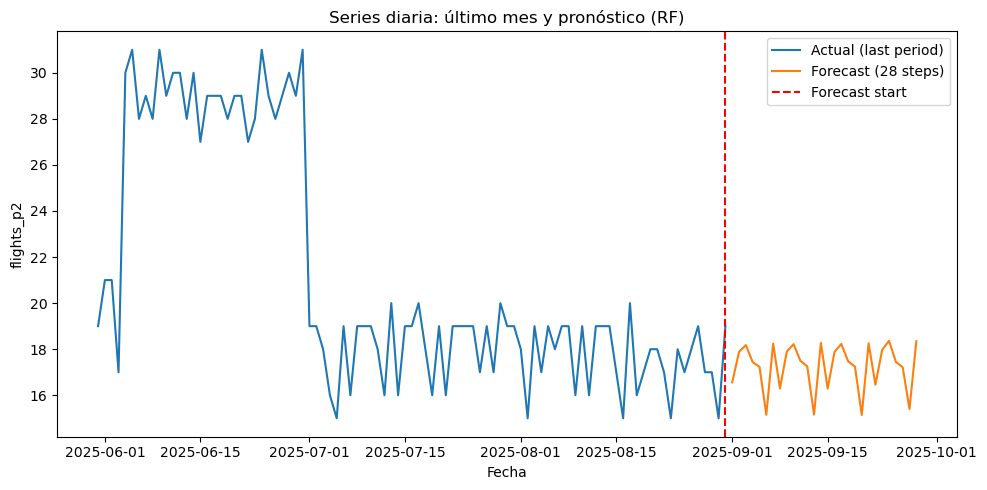

In [36]:

ts_col, y_col = "day", "flights_p2"
df_daily = df2.copy()
df_daily[ts_col] = pd.to_datetime(df_daily[ts_col])
y_daily = (df_daily
           .sort_values(ts_col)
           .set_index(ts_col)[y_col]
           .asfreq("D")  # daily cadence
           .fillna(0.0).astype(float))

rf = RandomForestDailyRegressor().fit(df_daily, date_col=ts_col, target_col=y_col)

h = 28
future_idx = pd.date_range(start=y_daily.index.max() + pd.Timedelta(days=1),
                           periods=h, freq="D")
future_df = pd.DataFrame({ts_col: future_idx})
fc_daily = rf.predict(future_df)
fc_daily.index = future_idx 
plot_last_period_with_forecast(
    actual=y_daily,
    forecast=fc_daily,
    period=pd.DateOffset(months=3),
    title="Series diaria: último mes y pronóstico (RF)",
    ylabel=y_col
)


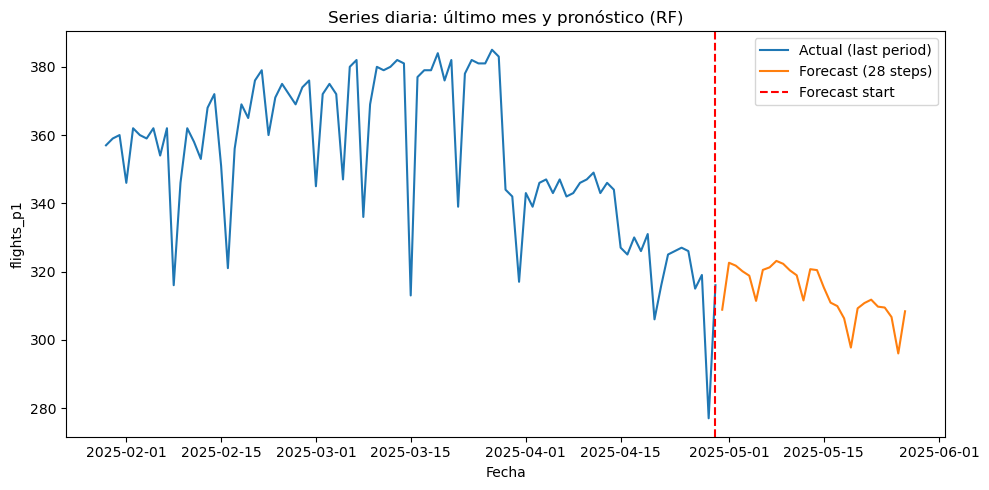

In [37]:

ts_col, y_col = "day", "flights_p1"
df_daily = df1.copy()
df_daily[ts_col] = pd.to_datetime(df_daily[ts_col])
y_daily = (df_daily
           .sort_values(ts_col)
           .set_index(ts_col)[y_col]
           .asfreq("D")  # daily cadence
           .fillna(0.0).astype(float))

rf = RandomForestDailyRegressor().fit(df_daily, date_col=ts_col, target_col=y_col)

h = 28
future_idx = pd.date_range(start=y_daily.index.max() + pd.Timedelta(days=1),
                           periods=h, freq="D")
future_df = pd.DataFrame({ts_col: future_idx})
fc_daily = rf.predict(future_df)
fc_daily.index = future_idx 
plot_last_period_with_forecast(
    actual=y_daily,
    forecast=fc_daily,
    period=pd.DateOffset(months=3),
    title="Series diaria: último mes y pronóstico (RF)",
    ylabel=y_col
)


In [38]:
# get the average of PPV in df1
avg_ppv = df1["PPV"].mean()
avg_ppv

273.9764428739694

In [39]:
fc_daily_df = fc_daily.reset_index()
fc_daily_df.columns = ['day', 'flights_p1_pred']
fc_daily_df.head()

fc_daily_df['Passengers'] = (fc_daily_df['flights_p1_pred'] * avg_ppv).round(0).astype("Int64")
fc_daily_df


,day,flights_p1_pred,Passengers
0,2025-04-30,308.830000,84612
1,2025-05-01,322.585000,88381
2,2025-05-02,321.731667,88147
3,2025-05-03,320.080000,87694
4,2025-05-04,318.785000,87340
5,2025-05-05,311.405000,85318
6,2025-05-06,320.485000,87805
7,2025-05-07,321.231667,88010
8,2025-05-08,323.120000,88527
9,2025-05-09,322.278333,88297
